In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load and preprocess CIFAR10 dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to [0, 1]
train_images, test_images = train_images / 255.0, test_images / 255.0

/Users/idristabi/Projects/school/cec_621 2/.venv/lib/python3.13/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [3]:
# Convert labels to one-hot encoding
train_labels = tf.keras.utils.to_categorical(train_labels, 10)
test_labels = tf.keras.utils.to_categorical(test_labels, 10)

In [4]:
# Create validation split (10% of training data)
val_split = 0.1
val_samples = int(len(train_images) * val_split)
val_images, val_labels = train_images[:val_samples], train_labels[:val_samples]
train_images, train_labels = train_images[val_samples:], train_labels[val_samples:]

In [5]:
# Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

/Users/idristabi/Projects/school/cec_621 2/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
# Define callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model_cifar10.keras',
        save_best_only=True,
        monitor='val_accuracy'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-7
    ),
    tf.keras.callbacks.TensorBoard(log_dir='./logs')
]


In [8]:
# Train model
history = model.fit(
    train_images, train_labels,
    epochs=100,
    batch_size=64,
    validation_data=(val_images, val_labels),
    callbacks=callbacks
)

Epoch 1/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.4457 - loss: 1.5672 - val_accuracy: 0.5346 - val_loss: 1.3247 - learning_rate: 0.0010
Epoch 2/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 52ms/step - accuracy: 0.5893 - loss: 1.1649 - val_accuracy: 0.5576 - val_loss: 1.3001 - learning_rate: 0.0010
Epoch 3/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.6498 - loss: 0.9953 - val_accuracy: 0.6852 - val_loss: 0.9005 - learning_rate: 0.0010
Epoch 4/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.6896 - loss: 0.8850 - val_accuracy: 0.6850 - val_loss: 0.8928 - learning_rate: 0.0010
Epoch 5/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.7202 - loss: 0.7990 - val_accuracy: 0.6612 - val_loss: 1.0270 - learning_rate: 0.0010
Epoch 6/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.7418 - loss: 0.7295 - val_accuracy: 0.7070 - val_loss: 0.8420 - learning_rate: 0.0010
Epoch 7/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.7

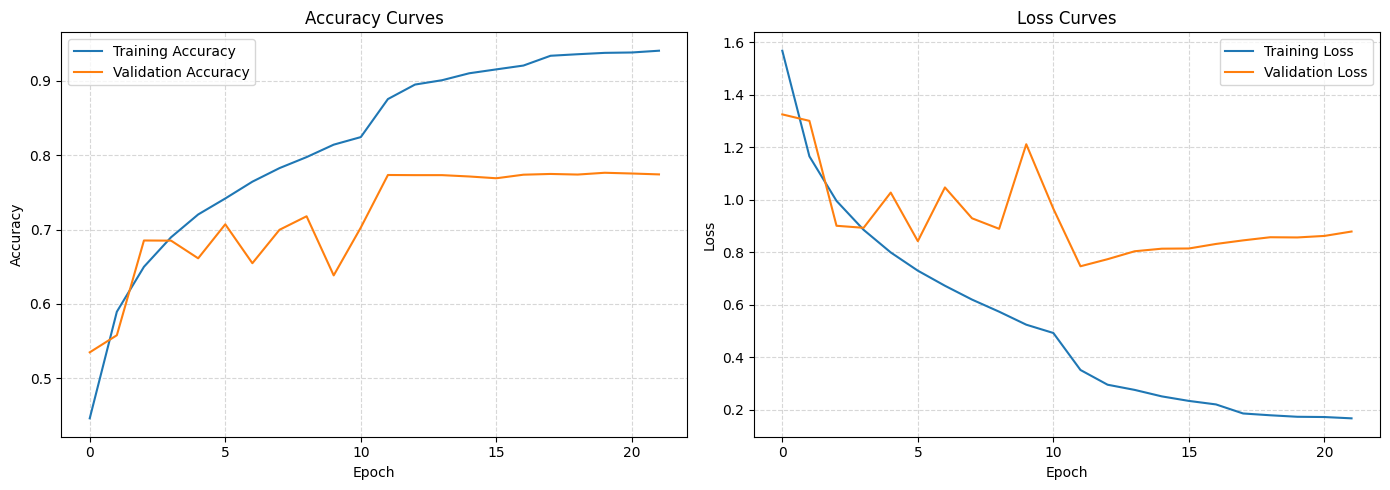

In [9]:
# Plot training history
def plot_history(history):
    plt.figure(figsize=(14, 5))
    
    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(linestyle='--', alpha=0.5)
    
    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300)
    plt.show()

plot_history(history)

In [10]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f'\nTest accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}')

# Optional: Save final model
model.save('cifar10_cnn_final.keras')


Test accuracy: 0.7650, Test loss: 0.7708
